In [1]:
!pip install h2o

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 266.4/266.4 MB 3.7 MB/s eta 0:00:00


In [ ]:
import os

import h2o
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from h2o.automl import H2OAutoML
from scipy.stats import spearmanr
from sklearn.preprocessing import StandardScaler

In [ ]:
USE_GOOGLE_COLAB = False

if USE_GOOGLE_COLAB:
    from google.colab import drive

    drive.mount('/content/drive')
    PARQUET_PATH = os.path.join(os.getcwd(), 'drive', 'MyDrive', 'DSE_260A', 'data', 'cleaned_data')
    CHALLENGE_DATA_PATH = os.path.join(os.getcwd(), 'drive', 'MyDrive', 'DSE_260A', 'data', 'cleaned_data')
    SUBMISSION_PATH = os.getcwd()
else:
    PARQUET_PATH = 'cleaned_data'
    CHALLENGE_DATA_PATH = '../cleaned_data'
    SUBMISSION_PATH = 'submission'

#Final Data cleaning for Task 4.1

In [17]:
df_train = pd.read_parquet(PARQUET_PATH + "/merged_data/combined.parquet")
challenge_participants = pd.read_csv(CHALLENGE_DATA_PATH + '/challenge_participants_cleaned.csv')
challenge_hai = pd.read_csv(CHALLENGE_DATA_PATH + '/challenge_hai_cleaned.csv')
challenge_transcriptomics = pd.read_parquet(CHALLENGE_DATA_PATH + '/challenge_transcriptomics_cleaned.parquet')
df_challenge = challenge_hai.merge(challenge_participants, on='participant_id', how='inner')
df_challenge = df_challenge.merge(challenge_transcriptomics, on='participant_id', how='inner')

In [18]:
#drop any d28 HAI columns which are not the target column (HAI_H1N1 A/Victoria/4897/2022_d28)
df_train = df_train.drop(columns=[c for c in df_train.columns if c.endswith('_d28') and c.startswith(
    'HAI') and c != 'HAI_H1N1 A/Victoria/4897/2022_d28'])

#filter out participants who do not have a baseline measurement for H1N1 A/Victoria/4897/2022 at day 0
df_train = df_train[df_train['HAI_H1N1 A/Victoria/4897/2022_d28'].isna() == False]

#filter out columns which are all NaN
df_train = df_train.dropna(axis=1, how='all')

In [19]:
df_train['DELTA'] = df_train['HAI_H1N1 A/Victoria/4897/2022_d28'] - df_train['HAI_H1N1 A/Victoria/4897/2022_d0']
df_train.drop(columns=['HAI_H1N1 A/Victoria/4897/2022_d28'], inplace=True)

df_train['DELTA'].value_counts()

,count
DELTA,
0.0,152
1.0,20
2.0,10
-1.0,6
3.0,6
-3.0,4
3.0,3
-2.0,3
4.0,3


In [20]:
df_train

,participant_id,PART_biological_sex,PART_race,PART_geolocation,PART_arm_name,PART_age,HAI_H1N1 A/Brisbane/2/2018_d0,HAI_H1N1 A/California/7/2009_d0,HAI_H1N1 A/Guangdong-Maonan/SWL1536/2019_d0,HAI_H1N1 A/Victoria/2570/2019_d0,...,HAI_H3N2 A/Hong Kong/2671/2019_d0,HAI_H3N2 A/Kansas/14/2017_d0,HAI_H3N2 A/Singapore/INFIMH-160019/2016_d0,HAI_H3N2 A/South Australia/34/2019_d0,HAI_H3N2 A/Tasmania/503/2020_d0,HAI_Vic B/Austria/1359417/2021_d0,HAI_Vic B/Colorado/6/2017_d0,HAI_Vic B/Washington/2/2019_d0,HAI_Yam B/Phuket/3073/2013_d0,DELTA
3466,2023_UGA.ID_002,Male,Unknown,Georgia,Standard Fluzone,46.0,6.321928,6.321928,2.321928,6.321928,...,6.321928,5.321928,4.321928,5.321928,7.321928,6.321928,6.321928,7.321928,5.321928,0.0
3467,2023_UGA.ID_014,Female,Unknown,Georgia,High Dose Fluzone,68.0,3.321928,3.321928,2.321928,2.321928,...,4.321928,3.321928,4.321928,6.321928,8.321928,3.321928,2.321928,2.321928,6.321928,0.0
3468,2023_UGA.ID_039,Female,Unknown,Georgia,Standard Fluzone,28.0,8.321928,7.321928,6.321928,3.321928,...,8.321928,6.321928,8.321928,9.321928,9.321928,2.321928,2.321928,2.321928,8.321928,0.0
3469,2023_UGA.ID_058,Female,Unknown,Georgia,Standard Fluzone,63.0,4.321928,4.321928,2.321928,2.321928,...,7.321928,5.321928,7.321928,7.321928,8.321928,5.321928,3.321928,2.321928,6.321928,0.0
3470,2023_UGA.ID_065,Female,Unknown,Georgia,Standard Fluzone,30.0,7.321928,8.321928,4.321928,5.321928,...,9.321928,5.321928,8.321928,7.321928,8.321928,4.321928,7.321928,3.321928,9.321928,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3679,2023_UGA.ID_750,Female,Unknown,Georgia,Standard Fluzone,26.0,4.321928,4.321928,2.321928,2.321928,...,3.321928,2.321928,3.321928,4.321928,7.321928,2.321928,2.321928,2.321928,6.321928,0.0
3680,2023_UGA.ID_751,Male,Unknown,Georgia,Standard Fluzone,29.0,7.321928,7.321928,5.321928,6.321928,...,8.321928,3.321928,4.321928,7.321928,8.321928,2.321928,2.321928,2.321928,5.321928,0.0
3681,2023_UGA.ID_753,Female,Unknown,Georgia,Standard Fluzone,64.0,8.321928,8.321928,7.321928,6.321928,...,9.321928,6.321928,7.321928,8.321928,8.321928,4.321928,4.321928,4.321928,7.321928,1.0
3682,2023_UGA.ID_754,Female,Unknown,Georgia,Standard Fluzone,39.0,6.321928,5.321928,4.321928,2.321928,...,3.321928,2.321928,3.321928,2.321928,5.321928,4.321928,2.321928,2.321928,5.321928,7.0


In [21]:
#figure out which columns are common to challenge and train set

challenge_cols = set(list(df_challenge.columns))
train_cols = set(list(df_train.columns))

common_cols = challenge_cols.intersection(train_cols)
print(common_cols)

missing_from_chal = train_cols - common_cols
print(missing_from_chal)





{'HAI_H3N2 A/Tasmania/503/2020_d0', 'PART_race', 'HAI_Yam B/Phuket/3073/2013_d0', 'HAI_H3N2 A/Darwin/9/2021_d0', 'HAI_H1N1 A/Victoria/4897/2022_d0', 'HAI_H3N2 A/Kansas/14/2017_d0', 'HAI_Vic B/Austria/1359417/2021_d0', 'HAI_H1N1 A/Brisbane/2/2018_d0', 'HAI_Vic B/Washington/2/2019_d0', 'PART_arm_name', 'HAI_H3N2 A/Hong Kong/2671/2019_d0', 'PART_geolocation', 'PART_age', 'HAI_H1N1 A/Guangdong-Maonan/SWL1536/2019_d0', 'PART_biological_sex', 'HAI_H3N2 A/South Australia/34/2019_d0', 'participant_id', 'HAI_H1N1 A/California/7/2009_d0', 'HAI_H1N1 A/Victoria/2570/2019_d0', 'HAI_H3N2 A/Singapore/INFIMH-160019/2016_d0', 'HAI_Vic B/Colorado/6/2017_d0'}
{'DELTA'}


In [22]:
df_train.drop(columns=['PART_race', 'PART_geolocation'],
              inplace=True)  #dropping race/geolocation since they are all the same val "unknown"/'Georgia'
df_train['PART_arm_name'] = df_train['PART_arm_name'].apply(lambda x: 1.0 if x == 'High Dose Fluzone' else 0.0)
df_train['PART_biological_sex'] = df_train['PART_biological_sex'].apply(lambda x: 1.0 if x == 'Male' else -1.0)

scaler = StandardScaler()
df_train['PART_age'] = scaler.fit_transform(df_train[['PART_age']])
df_train


,participant_id,PART_biological_sex,PART_arm_name,PART_age,HAI_H1N1 A/Brisbane/2/2018_d0,HAI_H1N1 A/California/7/2009_d0,HAI_H1N1 A/Guangdong-Maonan/SWL1536/2019_d0,HAI_H1N1 A/Victoria/2570/2019_d0,HAI_H1N1 A/Victoria/4897/2022_d0,HAI_H3N2 A/Darwin/9/2021_d0,HAI_H3N2 A/Hong Kong/2671/2019_d0,HAI_H3N2 A/Kansas/14/2017_d0,HAI_H3N2 A/Singapore/INFIMH-160019/2016_d0,HAI_H3N2 A/South Australia/34/2019_d0,HAI_H3N2 A/Tasmania/503/2020_d0,HAI_Vic B/Austria/1359417/2021_d0,HAI_Vic B/Colorado/6/2017_d0,HAI_Vic B/Washington/2/2019_d0,HAI_Yam B/Phuket/3073/2013_d0,DELTA
3466,2023_UGA.ID_002,1.0,0.0,-0.487221,6.321928,6.321928,2.321928,6.321928,2.321928,2.321928,6.321928,5.321928,4.321928,5.321928,7.321928,6.321928,6.321928,7.321928,5.321928,0.0
3467,2023_UGA.ID_014,-1.0,1.0,0.747778,3.321928,3.321928,2.321928,2.321928,2.321928,4.321928,4.321928,3.321928,4.321928,6.321928,8.321928,3.321928,2.321928,2.321928,6.321928,0.0
3468,2023_UGA.ID_039,-1.0,0.0,-1.497674,8.321928,7.321928,6.321928,3.321928,2.321928,4.321928,8.321928,6.321928,8.321928,9.321928,9.321928,2.321928,2.321928,2.321928,8.321928,0.0
3469,2023_UGA.ID_058,-1.0,0.0,0.467096,4.321928,4.321928,2.321928,2.321928,2.321928,6.321928,7.321928,5.321928,7.321928,7.321928,8.321928,5.321928,3.321928,2.321928,6.321928,0.0
3470,2023_UGA.ID_065,-1.0,0.0,-1.385401,7.321928,8.321928,4.321928,5.321928,2.321928,3.321928,9.321928,5.321928,8.321928,7.321928,8.321928,4.321928,7.321928,3.321928,9.321928,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3679,2023_UGA.ID_750,-1.0,0.0,-1.609946,4.321928,4.321928,2.321928,2.321928,2.321928,2.321928,3.321928,2.321928,3.321928,4.321928,7.321928,2.321928,2.321928,2.321928,6.321928,0.0
3680,2023_UGA.ID_751,1.0,0.0,-1.441538,7.321928,7.321928,5.321928,6.321928,2.321928,2.321928,8.321928,3.321928,4.321928,7.321928,8.321928,2.321928,2.321928,2.321928,5.321928,0.0
3681,2023_UGA.ID_753,-1.0,0.0,0.523233,8.321928,8.321928,7.321928,6.321928,5.321928,3.321928,9.321928,6.321928,7.321928,8.321928,8.321928,4.321928,4.321928,4.321928,7.321928,1.0
3682,2023_UGA.ID_754,-1.0,0.0,-0.880175,6.321928,5.321928,4.321928,2.321928,2.321928,2.321928,3.321928,2.321928,3.321928,2.321928,5.321928,4.321928,2.321928,2.321928,5.321928,7.0


#Data preprocessing for the challenge set:

In [23]:
df_challenge = df_challenge[list(common_cols)]
df_challenge['PART_arm_name'] = df_challenge['PART_arm_name'].apply(lambda x: 1.0 if x == 'High Dose Fluzone' else 0.0)
df_challenge['PART_biological_sex'] = df_challenge['PART_biological_sex'].apply(lambda x: 1.0 if x == 'Male' else -1.0)
df_challenge['PART_age'] = scaler.transform(df_challenge[['PART_age']])
df_challenge

,HAI_H3N2 A/Tasmania/503/2020_d0,PART_race,HAI_Yam B/Phuket/3073/2013_d0,HAI_H3N2 A/Darwin/9/2021_d0,HAI_H1N1 A/Victoria/4897/2022_d0,HAI_H3N2 A/Kansas/14/2017_d0,HAI_Vic B/Austria/1359417/2021_d0,HAI_H1N1 A/Brisbane/2/2018_d0,HAI_Vic B/Washington/2/2019_d0,PART_arm_name,...,PART_geolocation,PART_age,HAI_H1N1 A/Guangdong-Maonan/SWL1536/2019_d0,PART_biological_sex,HAI_H3N2 A/South Australia/34/2019_d0,participant_id,HAI_H1N1 A/California/7/2009_d0,HAI_H1N1 A/Victoria/2570/2019_d0,HAI_H3N2 A/Singapore/INFIMH-160019/2016_d0,HAI_Vic B/Colorado/6/2017_d0
0,3.321928,Unknown,4.321928,2.321928,2.321928,3.321928,4.321928,2.321928,2.321928,1.0,...,Georgia,0.972323,2.321928,-1.0,6.321928,2024_UGA.ID_077,4.321928,2.321928,3.321928,2.321928
1,3.321928,Unknown,5.321928,2.321928,4.321928,2.321928,5.321928,8.321928,4.321928,1.0,...,Georgia,0.579369,9.321928,1.0,4.321928,2024_UGA.ID_086,9.321928,6.321928,2.321928,5.321928
2,7.321928,Unknown,5.321928,6.321928,5.321928,7.321928,3.321928,6.321928,3.321928,0.0,...,Georgia,-0.655629,6.321928,-1.0,8.321928,2024_UGA.ID_128,7.321928,6.321928,7.321928,3.321928
3,6.321928,Unknown,3.321928,3.321928,2.321928,4.321928,3.321928,3.321928,2.321928,1.0,...,Georgia,1.084595,3.321928,-1.0,5.321928,2024_UGA.ID_170,3.321928,5.321928,4.321928,2.321928
4,3.321928,Unknown,7.321928,4.321928,2.321928,6.321928,5.321928,5.321928,4.321928,1.0,...,Georgia,0.860050,2.321928,-1.0,4.321928,2024_UGA.ID_179,3.321928,6.321928,2.321928,4.321928
5,8.321928,Unknown,3.321928,5.321928,2.321928,6.321928,4.321928,2.321928,4.321928,0.0,...,Georgia,-0.655629,2.321928,-1.0,8.321928,2024_UGA.ID_215,3.321928,2.321928,6.321928,5.321928
6,4.321928,Unknown,6.321928,3.321928,2.321928,3.321928,5.321928,6.321928,7.321928,0.0,...,Georgia,-0.543357,6.321928,1.0,4.321928,2024_UGA.ID_219,6.321928,5.321928,2.321928,7.321928
7,4.321928,Unknown,7.321928,2.321928,3.321928,3.321928,4.321928,3.321928,4.321928,1.0,...,Georgia,1.421413,5.321928,-1.0,3.321928,2024_UGA.ID_275,2.321928,3.321928,2.321928,4.321928
8,2.321928,Unknown,4.321928,2.321928,4.321928,4.321928,9.321928,6.321928,4.321928,1.0,...,Georgia,0.916187,5.321928,-1.0,4.321928,2024_UGA.ID_295,2.321928,6.321928,2.321928,5.321928
9,2.321928,Unknown,3.321928,2.321928,2.321928,2.321928,4.321928,5.321928,4.321928,1.0,...,Georgia,0.972323,4.321928,1.0,4.321928,2024_UGA.ID_296,4.321928,3.321928,2.321928,3.321928


In [25]:
df_train.to_parquet(os.path.join(os.getcwd(), '4.1_train_temp.parquet'), index=False)

# Task 4.1

**4.1 predict magnitude of antibody response - H1N1 A/Victoria/4897/2022 (D28)**
* Training Data: Demographics + Day 0 + Day 7 innate
* Assay: HAI
* Measure: Single strain titer
* Metric: Spearman correlation
* Full description: HAI titer for H1N1 A/Victoria/4897/2022 at Day 28

In [29]:
TARGET_COL = 'DELTA'  # task 4.1

## Task 4.1: BASELINE LINNEAR REGRESSION MODEL
Magnitude refers to the strength of the antibody response against a single specific vaccine strain.
We are predicting the HAI titer for H1N1 A/Victoria/4897/2022 at Day 28 post-vaccination.

In [26]:
h2o.init()

Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
  Java Version: openjdk version "17.0.18" 2026-01-20; OpenJDK Runtime Environment (build 17.0.18+8-Ubuntu-122.04.1); OpenJDK 64-Bit Server VM (build 17.0.18+8-Ubuntu-122.04.1, mixed mode, sharing)
  Starting server from /usr/local/lib/python3.12/dist-packages/h2o/backend/bin/h2o.jar
  Ice root: /tmp/tmpwo0hy0kq
  JVM stdout: /tmp/tmpwo0hy0kq/h2o_unknownUser_started_from_python.out
  JVM stderr: /tmp/tmpwo0hy0kq/h2o_unknownUser_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.


H2O_cluster_uptime:,02 secs
H2O_cluster_timezone:,Etc/UTC
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.10
H2O_cluster_version_age:,1 month and 24 days
H2O_cluster_name:,H2O_from_python_unknownUser_x3jnku
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,12.75 Gb
H2O_cluster_total_cores:,8
H2O_cluster_allowed_cores:,8
H2O_cluster_status:,"locked, healthy"


In [30]:
data = h2o.import_file(os.path.join(os.getcwd(), '4.1_train_temp.parquet'))

Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%


In [31]:
x = [c for c in data.columns if c != 'participant_id']
y = TARGET_COL
x = [c for c in x if c != y]

In [32]:
train, test = data.split_frame(ratios=[.8], seed=1234)

In [35]:
aml = H2OAutoML(max_models=100, seed=1, nfolds=5,
                keep_cross_validation_predictions=True,
                max_runtime_secs=5400)

aml.train(x=x, y=y, training_frame=train)

AutoML progress: |
05:47:41.497: _min_rows param, The dataset size is too small to split for min_rows=100.0: must have at least 200.0 (weighted) rows, but have only 169.0.

███████████████████████████████████████████████████████████████| (done) 100%


Model Details
=============
H2ODeepLearningEstimator : Deep Learning
Model Key: DeepLearning_grid_3_AutoML_2_20260507_54739_model_2


Status of Neuron Layers: predicting DELTA, regression, gaussian distribution, Quadratic loss, 6,101 weights/biases, 80.4 KB, 1,024,140 training samples, mini-batch size 1
    layer    units    type              dropout    l1    l2    mean_rate             rate_rms               momentum    mean_weight            weight_rms           mean_bias             bias_rms
--  -------  -------  ----------------  ---------  ----  ----  --------------------  ---------------------  ----------  ---------------------  -------------------  --------------------  -----------------------
    1        18       Input             20.0
    2        50       RectifierDropout  40.0       0.0   0.0   0.007271768807226585  0.006996914744377136   0.0         -0.0387454984995889    0.580080509185791    -1.0167242324579857   0.6720631122589111
    3        50       RectifierDropout  40.0       0.0   0.0   0.011715949278656625  0.021031290292739868   0.0         -0.09304162639945862   0.44217026233673096  0.3480310042349053    0.7897486686706543
    4        50       RectifierDropout  40.0       0.0   0.0   0.014905128017044626  0.023999236524105072   0.0         -0.10678413905961207   0.27343881130218506  0.7264963194974473    0.5692253112792969
    5        1        Linear                       0.0   0.0   0.002127112335001584  0.0033398065716028214  0.0         -0.042970136143267154  0.22346973419189453  0.060985801731574404  1.0971281125650402e-154

ModelMetricsRegression: deeplearning
** Reported on train data. **

MSE: 0.21652013988347865
RMSE: 0.46531724649262535
MAE: 0.3131962716450062
RMSLE: NaN
Mean Residual Deviance: 0.21652013988347865

ModelMetricsRegression: deeplearning
** Reported on cross-validation data. **

MSE: 1.6572035963778888
RMSE: 1.2873242001834226
MAE: 0.723264383760788
RMSLE: NaN
Mean Residual Deviance: 1.6572035963778888

Cross-Validation Metrics Summary: 
                        mean       sd        cv_1_valid    cv_2_valid    cv_3_valid    cv_4_valid    cv_5_valid
----------------------  ---------  --------  ------------  ------------  ------------  ------------  ------------
aic                     nan        0         nan           nan           nan           nan           nan
loglikelihood           nan        0         nan           nan           nan           nan           nan
mae                     0.722048   0.228092  0.609742      0.545765      0.974598      0.963657      0.516479
mean_residual_deviance  1.65238    1.02891   1.25985       0.661146      2.84571       2.65749       0.837712
mse                     1.65238    1.02891   1.25985       0.661146      2.84571       2.65749       0.837712
r2                      0.0300163  0.140362  -0.0772125    0.276245      -0.0178344    -0.0264153    -0.00470149
residual_deviance       1.65238    1.02891   1.25985       0.661146      2.84571       2.65749       0.837712
rmse                    1.23358    0.404131  1.12243       0.813109      1.68692       1.63018       0.915266
rmsle                   nan        0         nan           nan           nan           nan           nan

Scoring History: 
    timestamp            duration          training_speed    epochs    iterations    samples      training_rmse    training_deviance    training_mae    training_r2
--  -------------------  ----------------  ----------------  --------  ------------  -----------  ---------------  -------------------  --------------  -------------
    2026-05-07 06:03:23  0.000 sec                           0         0             0            nan              nan                  nan             nan
    2026-05-07 06:03:23  1 min 23.492 sec  52812 obs/sec     10        1             1690         1.29209          1.6695               0.693288        0.00896346
    2026-05-07 06:03:28  1 min 28.505 sec  100870 obs/sec    3010      301           508690       0.39105  

In [36]:
lb = aml.leaderboard
print(lb.head(rows=lb.nrows))

model_id                                                                    rmse      mse       mae    rmsle    mean_residual_deviance
DeepLearning_grid_3_AutoML_2_20260507_54739_model_2                      1.28732  1.6572   0.723264      nan                   1.6572
DeepLearning_grid_3_AutoML_2_20260507_54739_model_6                      1.29012  1.66442  0.749671      nan                   1.66442
DeepLearning_grid_3_AutoML_2_20260507_54739_model_9                      1.29122  1.66725  0.68905       nan                   1.66725
DeepLearning_grid_3_AutoML_2_20260507_54739_model_11                     1.29425  1.67509  0.783361      nan                   1.67509
StackedEnsemble_AllModels_1_AutoML_2_20260507_54739                      1.29707  1.68238  0.782848      nan                   1.68238
StackedEnsemble_BestOfFamily_1_AutoML_2_20260507_54739                   1.30111  1.69288  0.803853      nan                   1.69288
XGBoost_lr_search_selection_AutoML_2_20260507_54739_sele

In [37]:
print(aml.leader)

Model Details
H2ODeepLearningEstimator : Deep Learning
Model Key: DeepLearning_grid_3_AutoML_2_20260507_54739_model_2


Status of Neuron Layers: predicting DELTA, regression, gaussian distribution, Quadratic loss, 6,101 weights/biases, 80.4 KB, 1,024,140 training samples, mini-batch size 1
    layer    units    type              dropout    l1    l2    mean_rate             rate_rms               momentum    mean_weight            weight_rms           mean_bias             bias_rms
--  -------  -------  ----------------  ---------  ----  ----  --------------------  ---------------------  ----------  ---------------------  -------------------  --------------------  -----------------------
    1        18       Input             20.0
    2        50       RectifierDropout  40.0       0.0   0.0   0.007271768807226585  0.006996914744377136   0.0         -0.0387454984995889    0.580080509185791    -1.0167242324579857   0.6720631122589111
    3        50       RectifierDropout  40.0       0.0

In [38]:
predictions = aml.leader.predict(test)

results = test[y].cbind(predictions["predict"])
results.columns = ["actual", "predicted"]

# Filter out rows where actual is NaN
results_clean = results[results["actual"].isna() == 0]

print(results_clean.head(20))

deeplearning prediction progress: |██████████████████████████████████████████████| (done) 100%
  actual    predicted
       0    0.225088
       0    0.300818
       0    0.350845
       0   -0.042929
       0    0.274645
       0    0.485206
       0    0.20355
       0    0.165677
      -3   -0.274612
       0    0.181921
       0    0.267954
      -1    0.0609979
       0    0.264842
       0    0.372604
       0    0.251531
       0    0.851234
       0    0.211588
       1    0.202349
       1    0.128666
       0    0.192232
[20 rows x 2 columns]



/usr/local/lib/python3.12/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"
/usr/local/lib/python3.12/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


Spearman (results_clean): -0.064  (p-value: 0.6828)


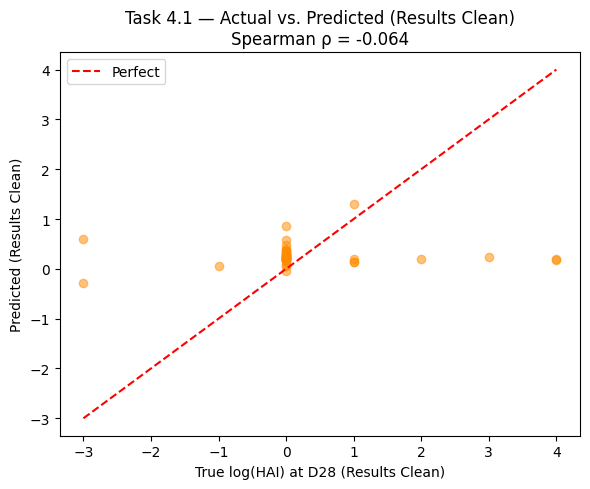

In [39]:
actual_values = results_clean['actual'].as_data_frame().to_numpy()
predicted_values = results_clean['predicted'].as_data_frame().to_numpy()

rho_results, pval_results = spearmanr(actual_values, predicted_values)
print(f'Spearman (results_clean): {rho_results:.3f}  (p-value: {pval_results:.4f})')

plt.figure(figsize=(6, 5))
plt.scatter(actual_values, predicted_values, alpha=0.5, color='darkorange')
plt.plot([actual_values.min(), actual_values.max()], [actual_values.min(), actual_values.max()], 'r--', label='Perfect')
plt.xlabel('True log(HAI) at D28 (Results Clean)')
plt.ylabel('Predicted (Results Clean)')
plt.title(f'Task 4.1 — Actual vs. Predicted (Results Clean)\nSpearman ρ = {rho_results:.3f}')
plt.legend()
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


First 5 actual HAI D28 values (Original Scale):
 [[5.]
 [5.]
 [5.]
 [5.]
 [5.]]

First 5 predicted HAI D28 values (Original Scale):
 [[5.84424454]
 [6.15921162]
 [6.37653735]
 [4.85341104]
 [6.04848092]]


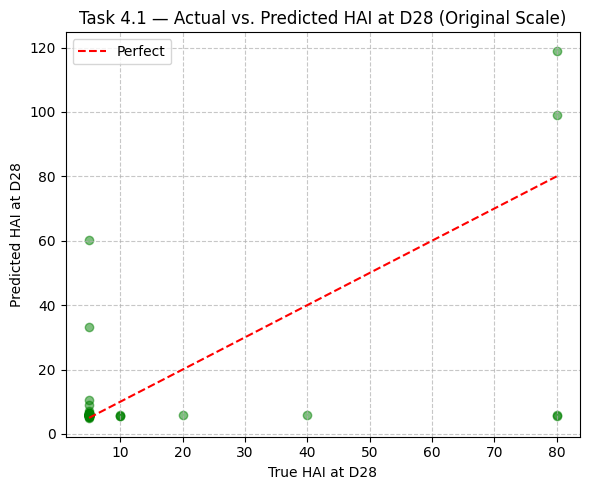

In [46]:
# Flag to toggle between log scale (1) and original scale (0) results
convert_to_original_scale = 0  # Set to 0 for original scale, 1 for log2 scale

# Get the Day 0 HAI values for the test set corresponding to the cleaned results
test_d0_hai_column_name = TARGET_COL.replace('DELTA', 'HAI_H1N1 A/Victoria/4897/2022_d0')

# Filter the original 'test' H2OFrame using the same condition that created results_clean.
# results_clean was created from `results[results["actual"].isna() == 0]`,
# where `results["actual"]` corresponds to `test[y]` for the relevant rows.
filtered_test_for_d0_h2o = test[test[y].isna() == 0]

# Now, extract the d0 HAI column from this filtered H2OFrame
test_d0_hai_h2o_filtered = filtered_test_for_d0_h2o[test_d0_hai_column_name]

# Convert it to a numpy array. The 'actual_values' and 'predicted_values' are already numpy arrays.
test_d0_hai = test_d0_hai_h2o_filtered.as_data_frame().values.reshape(-1, 1)

# Calculate actual HAI d28 values (log2 scale)
actual_hai_d28_log2 = test_d0_hai + actual_values

# Calculate predicted HAI d28 values (log2 scale)
predicted_hai_d28_log2 = test_d0_hai + predicted_values

if convert_to_original_scale == 0:
    # Convert to original HAI titer scale (exp2)
    display_actual_values = np.exp2(actual_hai_d28_log2)
    display_predicted_values = np.exp2(predicted_hai_d28_log2)
    scale_label = 'Original Scale'
    x_label = 'True HAI at D28'
    y_label = 'Predicted HAI at D28'
else:
    display_actual_values = actual_hai_d28_log2
    display_predicted_values = predicted_hai_d28_log2
    scale_label = 'Log2 Scale'
    x_label = 'True log2(HAI) at D28'
    y_label = 'Predicted log2(HAI) at D28'

print(f"First 5 actual HAI D28 values ({scale_label}):\n", display_actual_values[:5])
print(f"\nFirst 5 predicted HAI D28 values ({scale_label}):\n", display_predicted_values[:5])

# Plotting the HAI values
plt.figure(figsize=(6, 5))
plt.scatter(display_actual_values, display_predicted_values, alpha=0.5, color='green')
plt.plot([display_actual_values.min(), display_actual_values.max()],
         [display_actual_values.min(), display_actual_values.max()], 'r--', label='Perfect')
plt.xlabel(x_label)
plt.ylabel(y_label)
plt.title(f'Task 4.1 — Actual vs. Predicted HAI at D28 ({scale_label})')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [47]:
#calculate the spearman
rho_results, pval_results = spearmanr(display_actual_values, display_predicted_values)

print(f'Spearman: {rho_results}')

Spearman: -0.19337266525569274


#Use AutoML model to predict challenge set

In [56]:
challenge_hf = h2o.H2OFrame(df_challenge)
y_pred_challenge = aml.leader.predict(challenge_hf).as_data_frame()['predict']

results = pd.DataFrame({
    'participant_id': df_challenge['participant_id'].values,
    'Task_4.1': np.exp2(y_pred_challenge),
})

results = results.merge(df_challenge[['participant_id', 'HAI_H1N1 A/Victoria/4897/2022_d0']], on='participant_id',
                        how='inner')
results['Task_4.1'] = np.exp2(results['Task_4.1'] + results['HAI_H1N1 A/Victoria/4897/2022_d0'])
d0 = results.copy(deep=True)
results.drop(columns=['HAI_H1N1 A/Victoria/4897/2022_d0'], inplace=True)
results

Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
deeplearning prediction progress: |██████████████████████████████████████████████| (done) 100%


/usr/local/lib/python3.12/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


,participant_id,Task_4.1
0,2024_UGA.ID_077,10.957970
1,2024_UGA.ID_086,46.924198
2,2024_UGA.ID_128,427.227741
3,2024_UGA.ID_170,11.004878
4,2024_UGA.ID_179,11.265400
5,2024_UGA.ID_215,10.888215
6,2024_UGA.ID_219,11.014955
7,2024_UGA.ID_275,23.700172
8,2024_UGA.ID_295,45.963148
9,2024_UGA.ID_296,11.210373


In [57]:
d0


,participant_id,Task_4.1,HAI_H1N1 A/Victoria/4897/2022_d0
0,2024_UGA.ID_077,10.957970,2.321928
1,2024_UGA.ID_086,46.924198,4.321928
2,2024_UGA.ID_128,427.227741,5.321928
3,2024_UGA.ID_170,11.004878,2.321928
4,2024_UGA.ID_179,11.265400,2.321928
5,2024_UGA.ID_215,10.888215,2.321928
6,2024_UGA.ID_219,11.014955,2.321928
7,2024_UGA.ID_275,23.700172,3.321928
8,2024_UGA.ID_295,45.963148,4.321928
9,2024_UGA.ID_296,11.210373,2.321928


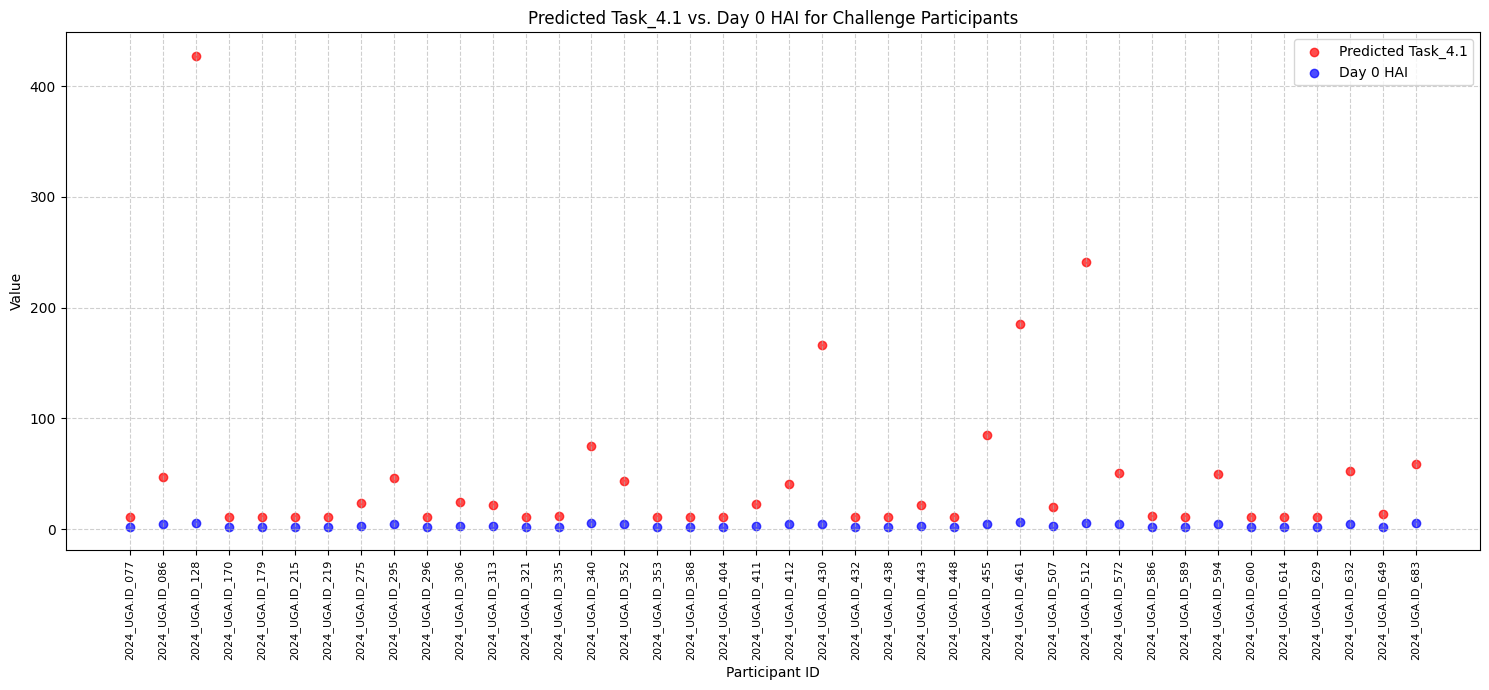

In [58]:
plt.figure(figsize=(15, 7))

# Plot predicted Task_4.1 values
plt.scatter(d0['participant_id'], d0['Task_4.1'], color='red', label='Predicted Task_4.1', alpha=0.7)

# Plot Day 0 HAI values (d0 value)
plt.scatter(d0['participant_id'], d0['HAI_H1N1 A/Victoria/4897/2022_d0'], color='blue', label='Day 0 HAI', alpha=0.7)

plt.xlabel('Participant ID')
plt.ylabel('Value')
plt.title('Predicted Task_4.1 vs. Day 0 HAI for Challenge Participants')
plt.xticks(rotation=90, fontsize=8)  # Rotate x-axis labels for readability
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [59]:
#output to csv

results.to_csv(SUBMISSION_PATH + '/task_4_1.csv', index=False)

# Task 4.7: BASELINE LINNEAR REGRESSION MODEL

**4.7 predict magnitude of antibody response - H1N1 A/Victoria/4897/2022 (D365)**
* Training Data: Demographics + Day 0 + Day 7 innate
* Assay: HAI
* Measure: Single strain titer
* Metric: Spearman correlation
* Full description: HAI titer for H1N1 A/Victoria/4897/2022 at Day 365

Since we do not have any d365 info for these participants we will just find some multiplier based on on d28 predictions

In [62]:
df_4_7 = d0.copy(deep=True)

df_4_7['Task_4.7'] = df_4_7['HAI_H1N1 A/Victoria/4897/2022_d0'] + (
        df_4_7['Task_4.1'] - df_4_7['HAI_H1N1 A/Victoria/4897/2022_d0']) * 0.1
df_4_7['Task_4.7'] = np.exp2(df_4_7['Task_4.7'])
df_4_7['Task_4.1'] = np.exp2(df_4_7['Task_4.1'])
df_4_7['HAI_H1N1 A/Victoria/4897/2022_d0'] = np.exp2(df_4_7['HAI_H1N1 A/Victoria/4897/2022_d0'])
df_4_7

,participant_id,Task_4.1,HAI_H1N1 A/Victoria/4897/2022_d0,Task_4.7
0,2024_UGA.ID_077,1.989196e+03,5.0,9.097892e+00
1,2024_UGA.ID_086,1.335338e+14,20.0,3.832535e+02
2,2024_UGA.ID_128,4.058494e+128,40.0,2.007661e+14
3,2024_UGA.ID_170,2.054936e+03,5.0,9.127521e+00
4,2024_UGA.ID_179,2.461632e+03,5.0,9.293843e+00
5,2024_UGA.ID_215,1.895306e+03,5.0,9.054009e+00
6,2024_UGA.ID_219,2.069340e+03,5.0,9.133899e+00
7,2024_UGA.ID_275,1.362896e+07,10.0,4.106258e+01
8,2024_UGA.ID_295,6.859402e+13,20.0,3.585549e+02
9,2024_UGA.ID_296,2.369510e+03,5.0,9.258462e+00


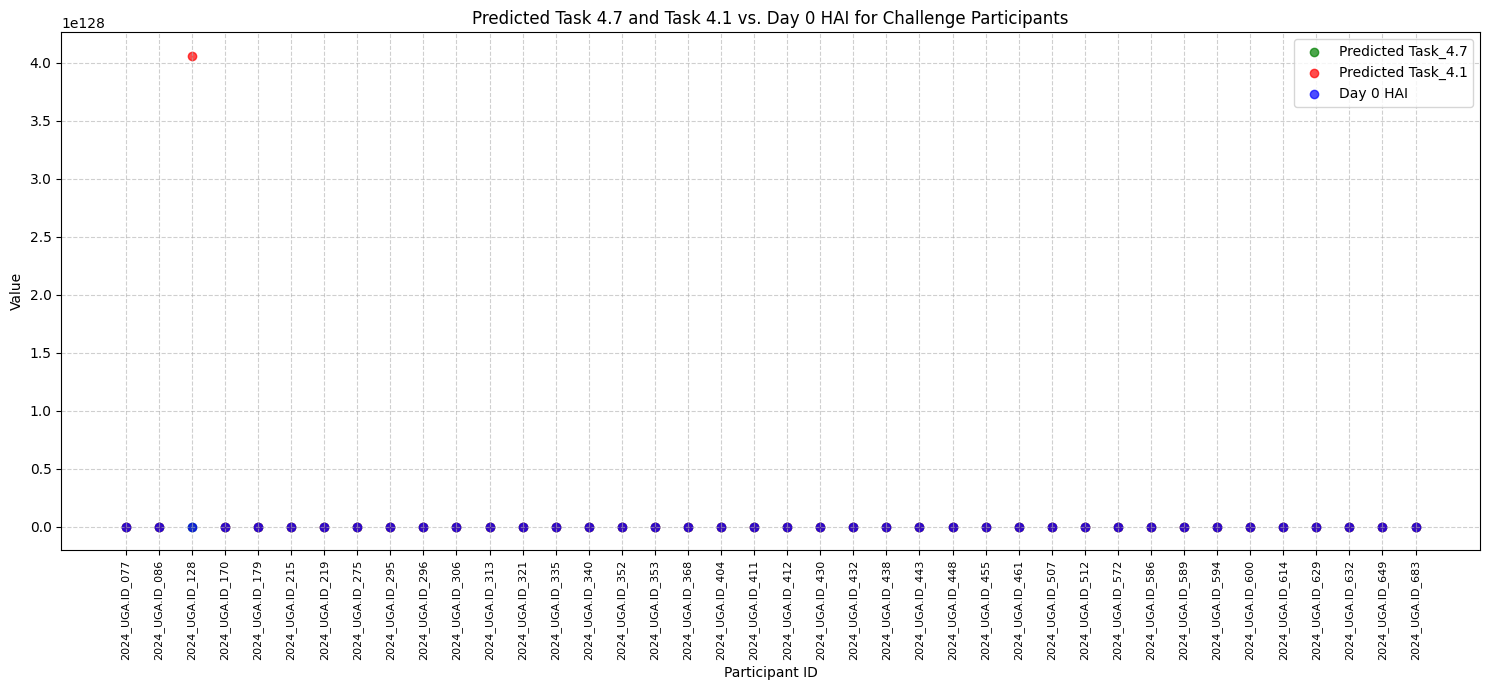

In [63]:
plt.figure(figsize=(15, 7))

# Plot predicted Task_4.7 values
plt.scatter(df_4_7['participant_id'], df_4_7['Task_4.7'], color='green', label='Predicted Task_4.7', alpha=0.7)

# Plot predicted Task_4.1 values
plt.scatter(df_4_7['participant_id'], df_4_7['Task_4.1'], color='red', label='Predicted Task_4.1', alpha=0.7)

# Plot Day 0 HAI values (d0 value)
plt.scatter(df_4_7['participant_id'], df_4_7['HAI_H1N1 A/Victoria/4897/2022_d0'], color='blue', label='Day 0 HAI',
            alpha=0.7)

plt.xlabel('Participant ID')
plt.ylabel('Value')
plt.title('Predicted Task 4.7 and Task 4.1 vs. Day 0 HAI for Challenge Participants')
plt.xticks(rotation=90, fontsize=8)  # Rotate x-axis labels for readability
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [64]:
#output to csv
df_4_7.drop(columns=['Task_4.1', 'HAI_H1N1 A/Victoria/4897/2022_d0'], inplace=True)
df_4_7.to_csv(SUBMISSION_PATH + '/task_4_7.csv', index=False)